# MNIST Neural Network (From Scratch only with Math)
CS229-style derivation with visualization
ReLU + Softmax, from scratch

## Dataset
$$
\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^{m}
$$
$$
x^{(i)} \in \mathbb{R}^{784}, \quad y^{(i)} \in \mathbb{R}^{10}
$$

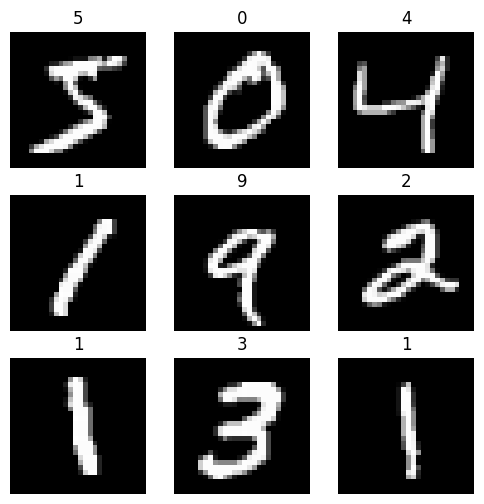

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from sklearn.model_selection import train_test_split

(X_train_full, Y_train_full), (X_test, Y_test) = mnist.load_data()

# Use train, validate and test split
X_train, X_val, Y_train, Y_val = train_test_split(X_train_full, Y_train_full, test_size=0.15, random_state=42)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(Y_train[i])
    plt.axis('off')
plt.show()

## Class Distribution

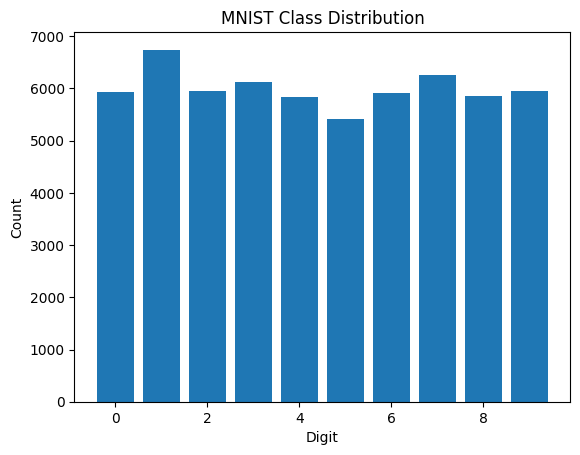

In [10]:
counts = np.bincount(Y_train)

plt.figure()
plt.bar(range(10), counts)
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("MNIST Class Distribution")
plt.show()


## Preprocessing
$$
X \in \mathbb{R}^{784 \times m}, \quad X = \frac{X}{255}
$$
$$
Y \in \mathbb{R}^{10 \times m}, \quad Y = \text{one-hot}(Y)
$$

In [11]:
X_train = X_train.reshape(-1, 784).T / 255.0
X_val = X_val.reshape(-1, 784).T / 255.0
X_test = X_test.reshape(-1, 784).T / 255.0

def one_hot(Y):
    one_hot_Y = np.zeros((10, Y.size))
    one_hot_Y[Y, np.arange(Y.size)] = 1
    return one_hot_Y

Y_train_oh = one_hot(Y_train)
Y_val_oh = one_hot(Y_val)

## Forward Propagation
$$ \mathbf{Z}^{[1]} = \mathbf{W}^{[1]}\mathbf{X} + \mathbf{b}^{[1]} $$
$$ \mathbf{A}^{[1]} = \max(0, \mathbf{Z}^{[1]}) $$
$$ \mathbf{Z}^{[2]} = \mathbf{W}^{[2]}\mathbf{A}^{[1]} + \mathbf{b}^{[2]} $$
$$ \mathbf{A}^{[2]} = \text{softmax}(\mathbf{Z}^{[2]}) $$


In [12]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


## Backpropagation
$$
dZ^{[2]} = A^{[2]} - Y
$$
$$
dZ^{[1]} = (W^{[2]})^T dZ^{[2]} \odot \mathbf{1}_{Z^{[1]} > 0}
$$

In [13]:
def relu_derivative(Z):
    return (Z > 0).astype(float)

def backward(X, Y, Z1, A1, A2, W2):
    m = X.shape[1]

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = (W2.T @ dZ2) * relu_derivative(Z1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2


## Parameter Update
$$
W := W - \alpha dW
$$
$$
b := b - \alpha db
$$

In [14]:
def init_params():
    W1 = np.random.randn(128, 784) * np.sqrt(2/784)
    b1 = np.zeros((128,1))
    W2 = np.random.randn(10,128) * np.sqrt(2/128)
    b2 = np.zeros((10,1))
    return W1,b1,W2,b2

def update(W1,b1,W2,b2,dW1,db1,dW2,db2,lr):
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2
    return W1,b1,W2,b2


In [15]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

W1,b1,W2,b2 = init_params()

for i in range(500):
    Z1,A1,Z2,A2 = forward(X_train,W1,b1,W2,b2)
    dW1,db1,dW2,db2 = backward(X_train,Y_train_oh,Z1,A1,A2,W2)
    W1,b1,W2,b2 = update(W1,b1,W2,b2,dW1,db1,dW2,db2,0.1)
    
    if i % 100 == 0:
        print(f"Iteration: {i}")
        predictions = get_predictions(A2)
        print(f"Training Accuracy: {get_accuracy(predictions, Y_train):.4f}")
        
        _, _, _, A2_val = forward(X_val, W1, b1, W2, b2)
        val_predictions = get_predictions(A2_val)
        print(f"Validation Accuracy: {get_accuracy(val_predictions, Y_val):.4f}")

## Final Test (Single Image)

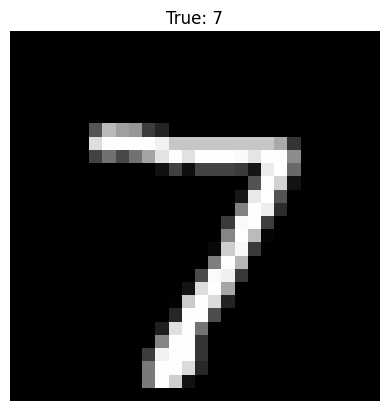

Prediction: 7


In [16]:
idx = 0
img = X_test[:, idx].reshape(28,28)

plt.imshow(img, cmap='gray')
plt.title("True: " + str(Y_test[idx]))
plt.axis('off')
plt.show()

_,_,_,A2 = forward(X_test[:, idx:idx+1], W1,b1,W2,b2)
pred = np.argmax(A2)

print("Prediction:", pred)
